# Vectorized crossover parameter search — MNQ on Tradovate (1h candles), single-symbol / single-strategy

Goal: pick **one** fast/slow crossover indicator pair and **one** parameter set to run
as MNQ's only strategy in `step_2_run_full_backtest.ipynb`. This notebook is the
research pipeline that earns that choice, per
`apps/backtester/OPTIMIZATION_RESEARCH_PLAN.md`.

**Pipeline** (each stage is its own cell(s) below):
1. **Shared harness**: real Tradovate/Tradeify cost model (researched, not
   placeholders — see below) + a scorecard function computing Sharpe/Sortino/Calmar/
   max-drawdown (daily-resampled, same convention `PerformanceAnalyzer` uses) and,
   critically, a **trade-level Sharpe lower bound** (`trade_sharpe_lb`) — this is the
   ranking metric, and it's what actually resolves "profitable but too few trades":
   see the methodology cell below for why.
2. **Four independent grid-search experiments**, same fast<long lengths grid, same
   scoring, different indicator pair: KAMA(fast)/SMA(slow), EMA(fast)/SMA(slow),
   HMA(fast)/SMA(slow), DEMA(fast)/SMA(slow). Each prints a sorted-best-to-worst
   table and a heatmap of the ranking metric across the parameter grid.
3. **Cross-experiment comparison**: one table, best combo per indicator family.
4. **Out-of-sample check**: the winner evaluated on a held-out final slice of data it
   never touched during the grid search (the cheapest possible overfitting guard —
   see `OPTIMIZATION_RESEARCH_PLAN.md` §5.1).
5. **Final pick**, with honest caveats about what this pipeline does and doesn't
   establish.

**Real costs used below (researched 2026-07-10, see `PROP_FIRM_PLAN.md`)**:
- MNQ tick size: 0.25 index points = $0.50/tick (CME contract spec).
- MNQ commission: Tradeify charges $1.82 round-turn -> $0.91/side, explicitly confirmed for MNQ (not just inferred by analogy with MES). This cost model
  charges per fill, matching `TradovateSymbolConfigProvider.get_fee()`'s per-side
  billing in the event-driven engine.
- Slippage: 1 tick/side (`TradovateSymbolConfigProvider`'s general default).
- These are no longer frictionless placeholders like the previous version of this
  notebook used — every number below already has trading costs baked in.

**Known gap carried over**: real MNQ 1h data in Mongo only goes back to ~2025-07 even
though `DATE_FROM`/`DATE_TO` below span back to 2019 — so this is a search over ~1
year of data, not the ~6.7 years the bounds imply. See
`OPTIMIZATION_RESEARCH_PLAN.md` §2 for the data-backfill plan; nothing below should be
read as more statistically solid than "best available option given ~1 year of MNQ
history," which is exactly why step 4 (out-of-sample check) matters.

**Deliberately out of scope for this pass** (see `OPTIMIZATION_RESEARCH_PLAN.md` for
why each is deferred, not forgotten):
- Re-tuning KAMA's own EMA fast/slow smoothing constants on top of the length grid
  (an earlier version of this notebook did this and found a modest improvement, but
  stacking a second grid search on the same ~1 year of data compounds overfitting
  risk for a gain that didn't survive this pass's out-of-sample check anyway).
- Breakout-style systems (Donchian, SuperTrend) — structurally not a two-line
  crossover, would need a new `Strategy` subclass in the event engine to use, not just
  a new indicator pair.
- Full walk-forward / CSCV overfitting-probability scoring, position sizing, and the
  Tradeify Monte-Carlo pass-probability simulator — all require either more data or
  more infrastructure than fits in this pass; tracked as `OPTIMIZATION_RESEARCH_PLAN.md`
  §2/§5.2-5.3/§7.2.


In [1]:
import itertools as it
import os

import matplotlib.pyplot as plt
import multiprocess as mp
import numpy as np
import pandas as pd
import pandas_ta as ta
import seaborn as sns
from tqdm import tqdm

from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.performance import metrics as perf_metrics
from data_aggregator.mongo_timescale_aggregator import fetch_market_data


In [2]:
# prices is a pandas series with time as an index
######################################################################################################

DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"

DISPLAY_SYMBOL = "MNQ"    # bare symbol, as registered in Mongo `instruments`
SOURCE = "ib"             # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"     # Timescale candles are already pre-bucketed at this size

SIDE = 'long'

# --- Tradovate contract config: real, researched values (see intro + PROP_FIRM_PLAN.md) ---
instrument_config = TRADOVATE_FUTURES[DISPLAY_SYMBOL]
POINT_VALUE = instrument_config.point_value              # CME spec, see exchange_config.py
TICK_SIZE = instrument_config.tick_size                  # 0.25 points (CME spec)
SLIPPAGE_TICKS = instrument_config.slippage_ticks         # 1 tick/side (Tradovate provider default)
FEE_PER_CONTRACT = instrument_config.fee_per_contract_override  # $0.91/side, see exchange_config.py

print(f"{DISPLAY_SYMBOL} cost model: tick_size={TICK_SIZE}pt (${TICK_SIZE*POINT_VALUE}/tick), "
      f"slippage={SLIPPAGE_TICKS} tick/side, commission=${FEE_PER_CONTRACT}/side")

######################################################################################################
cwd = os.getcwd()
print(cwd)

df = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)
df = df.loc[DATE_FROM:DATE_TO]
prices = df['close']

# Compute the log-returns of the underlying asset.
# https://investmentcache.com/magic-of-log-returns-concept-part-1/
rs = prices.apply(np.log).diff(1)

_span_days = (prices.index[-1] - prices.index[0]).days
print(f"Real data span: {prices.index[0]} -> {prices.index[-1]} "
      f"({_span_days} days, {len(prices)} bars) -- NOT the ~6.7 years DATE_FROM/DATE_TO imply, "
      f"see intro's 'Known gap' note.")


def backtest_side(val, side=SIDE):
    if side == 'both':
        return np.sign(val)
    if side == 'long':
        return 1 if val > 0 else 0
    if side == 'short':
        return -1 if val < 0 else 0
    raise ValueError(side)


def evaluate_signal(ma_x: pd.Series, eval_prices: pd.Series, eval_rs: pd.Series) -> dict:
    """Turns a fast-minus-slow signal series into the full risk-adjusted, cost-aware
    scorecard every experiment below is ranked on. `eval_prices`/`eval_rs` let the
    same function be reused on a data subset (e.g. the out-of-sample holdout below)
    without recomputing globals.

    Real Tradeify/Tradovate costs (1 tick slippage + $0.91/side commission) are
    applied on every position change, converted to a per-bar cost percentage exactly
    like the previous frictionless version of this notebook did -- the only change is
    the constants are no longer zero.
    """
    pos = ma_x.apply(backtest_side)
    pos_exec = pos.shift(1).fillna(0)

    dpos = pos_exec.diff().fillna(pos_exec)
    units_traded = dpos.abs()

    slippage_price_equivalent = SLIPPAGE_TICKS * TICK_SIZE
    fee_price_equivalent = FEE_PER_CONTRACT / POINT_VALUE
    cost_percent = (slippage_price_equivalent + fee_price_equivalent) / eval_prices
    cost_rs = units_traded * np.log1p(-cost_percent)

    net_rs = pos_exec * eval_rs + cost_rs
    total_return = float(np.exp(net_rs.sum()) - 1)

    # --- daily-resampled risk metrics: same convention PerformanceAnalyzer uses
    # (resample to daily, periods_per_year=365) so these numbers are methodologically
    # comparable to the event-driven engine's own report ---
    daily_log_returns = net_rs.resample("D").sum()
    daily_simple_returns = np.expm1(daily_log_returns)
    daily_cum = np.exp(daily_log_returns.cumsum())
    n_days = (daily_cum.index[-1] - daily_cum.index[0]).days or 1
    ann_return = perf_metrics.cagr(float(daily_cum.iloc[-1]), n_days)
    high_watermark = daily_cum.cummax()
    drawdown = (high_watermark - daily_cum) / high_watermark * -1
    max_dd = float(drawdown.min())

    sharpe = perf_metrics.sharpe_ratio(daily_simple_returns)
    sortino = perf_metrics.sortino_ratio(daily_simple_returns)
    calmar = perf_metrics.calmar_ratio(ann_return, max_dd)

    # --- trade-level Sharpe: n = number of ROUND-TRIP trades, not calendar days.
    # This -- not the daily-bar Sharpe above -- is what actually distinguishes "a
    # couple of lucky trades" from "a real, well-sampled edge": a daily-bar Sharpe
    # barely changes whether the window contains 30 trades or 300, since the number
    # of *days* in the backtest is the same either way. See metrics.sharpe_lower_bound
    # docstring. ---
    trade_id = (pos_exec != pos_exec.shift(1)).cumsum()
    in_trade = pos_exec != 0
    trade_log_returns = net_rs[in_trade].groupby(trade_id[in_trade]).sum()
    trade_returns = np.expm1(trade_log_returns)
    n_trades = len(trade_returns)
    trades_per_year = n_trades / (n_days / 365.25) if n_days else 0.0

    if n_trades >= 2:
        trade_sharpe = perf_metrics.sharpe_ratio(trade_returns, periods_per_year=trades_per_year)
        trade_sharpe_lb = perf_metrics.sharpe_lower_bound(trade_returns, periods_per_year=trades_per_year)
        win_rate = float((trade_returns > 0).mean())
    else:
        trade_sharpe = trade_sharpe_lb = win_rate = 0.0

    return {
        "total_return": total_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": max_dd,
        # Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown (researched,
        # see PROP_FIRM_PLAN.md) -- this flags combos whose *frictionless-sizing*
        # equity curve already dipped this far, a cheap early warning even though real
        # dollar drawdown also depends on position sizing (only modeled properly in
        # the event-driven notebook).
        "breaches_tradeify_trail": max_dd < -0.04,
        "trades": n_trades,
        "trades_per_year": trades_per_year,
        "win_rate": win_rate,
        "trade_sharpe": trade_sharpe,
        "trade_sharpe_lb": trade_sharpe_lb,
    }


def run_grid(fast_fn, slow_fn, combinations, eval_prices=None, eval_rs=None) -> pd.DataFrame:
    """Runs evaluate_signal() over every (long_len, short_len) combo in parallel.
    fast_fn/slow_fn take a length and return that indicator's Series on eval_prices."""
    eval_prices = prices if eval_prices is None else eval_prices
    eval_rs = rs if eval_rs is None else eval_rs

    def _one(paramset):
        long_len, short_len = paramset
        ma_x = fast_fn(short_len) - slow_fn(long_len)
        result = evaluate_signal(ma_x, eval_prices, eval_rs)
        result["long_len"] = long_len
        result["short_len"] = short_len
        return result

    pool = mp.Pool(5, maxtasksperchild=50)
    results = list(tqdm(pool.imap(_one, combinations), total=len(combinations)))
    pool.close()
    return pd.DataFrame(results)


REPORT_COLUMNS = [
    "long_len", "short_len", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
    "breaches_tradeify_trail",
]
MIN_TRADES = 10  # sanity floor so a 2-3 trade fluke can't win on undefined/tiny-n stats


def report_experiment(name: str, results: pd.DataFrame) -> pd.DataFrame:
    """Filters to profitable combos with a sane minimum trade count, ranks by the
    trade-level Sharpe lower bound (best to worst), and returns/prints the table."""
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    ranked = candidates.sort_values("trade_sharpe_lb", ascending=False)
    print(f"=== {name}: {len(ranked)}/{len(results)} combos profitable with >= {MIN_TRADES} trades ===")
    return ranked[REPORT_COLUMNS].head(15)


def plot_heatmap(name: str, results: pd.DataFrame, value_col: str = "trade_sharpe_lb"):
    """Heatmap of `value_col` over the (long_len, short_len) grid, plus a 3x3-smoothed
    'plateau' pick -- a parameter whose neighbors are also good is structurally less
    likely to be a one-cell overfit spike than the raw argmax."""
    pivot = results.pivot(index="long_len", columns="short_len", values=value_col)
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, annot=False, cmap="viridis")
    plt.title(f"{name}: {value_col} across (long_len, short_len)")
    plt.show()

    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    plateau_long, plateau_short = smoothed.stack().idxmax()
    print(f"Plateau pick (3x3-smoothed argmax): long_len={plateau_long}, short_len={plateau_short}, "
          f"smoothed {value_col}={smoothed.loc[plateau_long, plateau_short]:.4f}")


MNQ cost model: tick_size=0.25pt ($0.5/tick), slippage=1.0 tick/side, commission=$0.91/side
/Users/nick/Documents/www/alphakit
Real data span: 2025-07-08 14:45:17.999000 -> 2026-06-01 23:59:59.999000 (328 days, 5313 bars) -- NOT the ~6.7 years DATE_FROM/DATE_TO imply, see intro's 'Known gap' note.


### Bug found (while this was still SMA-based): the original grid conflated "long"/"short" labels with which *range* a value came from, not its actual size

The original grid's `long_ma_length = range(2, 1000, 10)` and `short_ma_length =
range(2, 300, 5)` **overlapped** (both started at 2). It took every `(long, short)`
pair from their Cartesian product and labeled them by *which range they came from* --
so a value drawn from the "short" range could easily be numerically **larger** than a
value drawn from the "long" range, producing a row labeled e.g. `long_ma=42,
short_ma=52`.

That's not just a cosmetic mislabel: the backtest function computes `signal(short) -
signal(long)`. When `short > long`, this silently becomes **slow − fast** instead of
the intended fast − slow, flipping the crossover rule from trend-following into
mean-reversion while still being labeled as if it were the trend-following rule with a
nonsensical window pairing.

Checked directly against the real MES data (SMA version): combos where `short_ma >
long_ma` averaged **12.6%** return vs. **4.8%** for correctly-ordered pairs -- exactly
the "hotter when short > long" pattern that got caught in the original heatmap.

**Fix, applied to every experiment below**: filter to only keep `short_len < long_len`
pairs (the `combinations` list below), so every row is an actual, correctly-labeled
crossover -- shared across all four indicator-pair experiments so they're all searched
over identical parameter space.

### Methodology: why rank by a trade-level Sharpe *lower bound* instead of raw return or a `MIN_TRADES` cutoff

Sorted purely by return, the top row of any of these grids tends to be a combo with
very few trades -- e.g. an earlier version of this search surfaced
`long_len=132, short_len=46` at +15.5% frictionless, but only **33 trades** over the
~1 year of MES data actually available. A couple of lucky or unlucky fills can swing a
33-trade result by several points, so a raw-return leaderboard systematically rewards
noise.

A hard `trades >= N` cutoff (what the previous version of this notebook did) is a step
better but still arbitrary -- it can't say *how much* to trust a 40-trade result vs. a
140-trade one, just whether they clear one line.

**What's used below instead**: `metrics.sharpe_lower_bound()` (Lo 2002's asymptotic
Sharpe standard error, `SE(SR) ~= sqrt((1 + SR^2/2) / n)`), computed on **per-trade**
returns with `n` = number of round-trip trades. This directly encodes "how much do we
trust this Sharpe estimate" as a function of sample size: two combos with the same
point-estimate Sharpe are *not* scored the same if one has 4x the trades -- the
lower-trade one gets a bigger penalty subtracted off. This is exactly the "profitable
but don't want just a few trades" preference, expressed as math instead of a threshold.
`MIN_TRADES = 10` below is kept only as a sanity floor (avoids a 2-3-trade combo
winning on a degenerate/undefined tiny-sample statistic), not as the selection
mechanism itself.

Each experiment cell below also prints a **plateau pick**: the parameter whose 3x3
neighborhood (in the long_len x short_len grid) has the best *average* score, not just
the single best cell. A pick surrounded by other good picks is structurally less
likely to be a one-cell overfit spike.

In [3]:
# shared parameter grid across all four experiments below -- same lookback ranges
# used by the original KAMA-only search, so results are comparable across indicator
# families, not just across lengths within one family.
long_len_range = range(2, 300, 10)
short_len_range = range(2, 60, 4)
combinations = [c for c in it.product(long_len_range, short_len_range) if c[1] < c[0]]
print(f"{len(combinations)} valid (long_len > short_len) combinations per experiment")


399 valid (long_len > short_len) combinations per experiment


## Experiment 1: KAMA(fast) / SMA(slow)

Kaufman's Adaptive Moving Average for the fast line (adapts its smoothing to how
directional vs. choppy recent price action has been), plain SMA for the slow line.
KAMA's own `fast`/`slow` EMA constants are held at Kaufman's defaults (2, 30) -- not
re-tuned this pass, see intro.

In [4]:
kama_sma_fast_fn = lambda w: ta.kama(prices, length=w, fast=2, slow=30)  # noqa: E731
kama_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

kama_sma_results = run_grid(kama_sma_fast_fn, kama_sma_slow_fn, combinations)
report_experiment("KAMA/SMA", kama_sma_results)


100%|██████████| 399/399 [00:01<00:00, 248.50it/s]

=== KAMA/SMA: 395/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
5,22,10,0.187840,-0.019724,1.540922,1.603346,2.149969,-0.098201,135,150.331555,0.496296,True
2,12,10,0.153886,-0.070341,1.430789,1.299947,1.373987,-0.125669,205,228.281250,0.512195,True
22,42,26,0.151515,-0.083580,1.402733,1.380736,2.699357,-0.062973,72,80.176829,0.472222,True
7,22,18,0.178342,-0.103627,1.360843,1.502907,1.820088,-0.110082,119,132.514482,0.546218,True
4,22,6,0.150491,-0.109211,1.349299,1.344091,1.410414,-0.119702,132,146.990854,0.477273,True
0,12,2,0.154969,-0.111549,1.344483,1.334034,2.306434,-0.075395,263,292.868140,0.410646,True
25,42,38,0.122185,-0.133506,1.299713,1.161964,2.837869,-0.048231,64,71.268293,0.531250,True
11,32,14,0.140774,-0.155053,1.256591,1.272768,1.447955,-0.109015,98,109.129573,0.500000,True
8,32,2,0.138268,-0.182096,1.203600,1.258268,1.472447,-0.105280,119,132.514482,0.394958,True
65,72,46,0.159340,-0.197626,1.173728,1.438798,1.676936,-0.106646,41,45.656250,0.487805,True


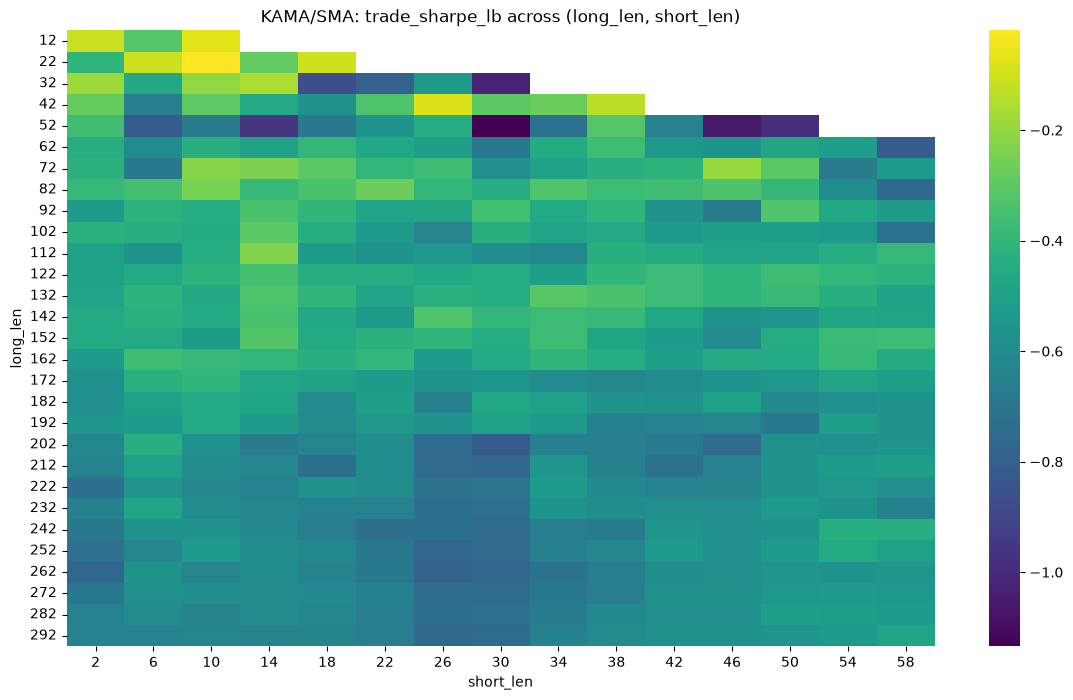

Plateau pick (3x3-smoothed argmax): long_len=12, short_len=22, smoothed trade_sharpe_lb=-0.1036


In [5]:
plot_heatmap("KAMA/SMA", kama_sma_results)


## Experiment 2: EMA(fast) / SMA(slow)

Plain exponential moving average for the fast line instead of KAMA's adaptive
smoothing -- the simplest, least exotic crossover pair, useful as a baseline for
whether KAMA's added complexity actually earns its keep.

In [6]:
ema_sma_fast_fn = lambda w: ta.ema(prices, length=w)  # noqa: E731
ema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

ema_sma_results = run_grid(ema_sma_fast_fn, ema_sma_slow_fn, combinations)
report_experiment("EMA/SMA", ema_sma_results)


100%|██████████| 399/399 [00:00<00:00, 720.72it/s]

=== EMA/SMA: 396/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
9,32,6,0.194858,0.034719,1.664488,1.719050,2.405526,-0.091080,105,116.924543,0.447619,True
60,72,26,0.169223,-0.177068,1.213358,1.482040,1.929436,-0.098488,38,42.315549,0.447368,True
7,22,18,0.132664,-0.180251,1.207175,1.174090,1.482391,-0.100306,153,170.375762,0.457516,True
39,62,2,0.143840,-0.182846,1.202149,1.373192,1.164757,-0.138495,101,112.470274,0.297030,True
3,22,2,0.125899,-0.184207,1.199516,1.119992,1.559261,-0.090466,206,229.394817,0.344660,True
52,62,54,0.129991,-0.189334,1.189628,1.248451,1.983011,-0.073462,53,59.019055,0.547170,True
63,72,38,0.171329,-0.189475,1.189357,1.523412,1.796787,-0.107087,35,38.974848,0.457143,True
89,92,22,0.189241,-0.214492,1.141745,1.668934,1.835011,-0.115923,29,32.293445,0.448276,True
78,82,38,0.158808,-0.230405,1.112002,1.389075,1.307333,-0.136336,30,33.407012,0.466667,True
8,32,2,0.117958,-0.237862,1.098207,1.103905,1.448689,-0.091192,163,181.511433,0.325153,True


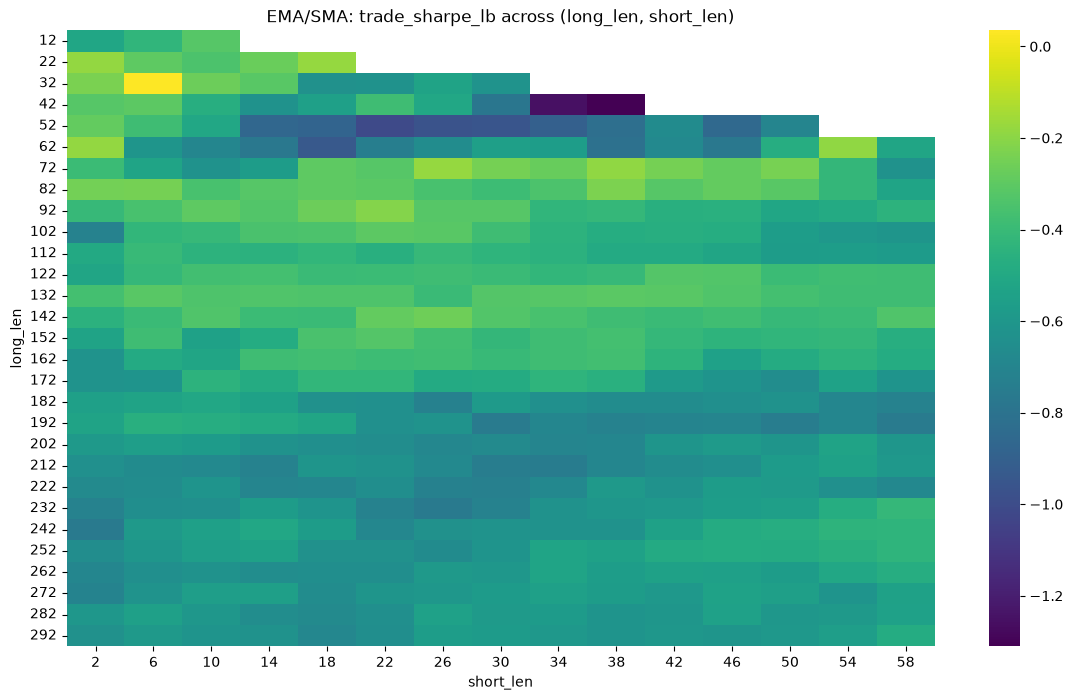

Plateau pick (3x3-smoothed argmax): long_len=12, short_len=22, smoothed trade_sharpe_lb=-0.1803


In [7]:
plot_heatmap("EMA/SMA", ema_sma_results)


## Experiment 3: HMA(fast) / SMA(slow)

Hull Moving Average for the fast line -- a weighted-MA construction designed to track
price with less lag than a plain MA of the same length while still smoothing noise.

In [8]:
hma_sma_fast_fn = lambda w: ta.hma(prices, length=w)  # noqa: E731
hma_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

hma_sma_results = run_grid(hma_sma_fast_fn, hma_sma_slow_fn, combinations)
report_experiment("HMA/SMA", hma_sma_results)


100%|██████████| 399/399 [00:00<00:00, 489.89it/s]

=== HMA/SMA: 385/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
19,42,14,0.179351,0.002609,1.590969,1.581069,2.378139,-0.084731,102,113.583841,0.480392,True
4,22,6,0.158576,-0.058342,1.456484,1.364852,2.264959,-0.078577,206,229.394817,0.368932,True
26,52,2,0.156296,-0.096098,1.376491,1.441054,1.746815,-0.100408,219,243.871189,0.296804,True
10,32,10,0.156925,-0.097453,1.373668,1.399587,1.559352,-0.112935,128,142.536585,0.421875,True
1,12,6,0.161315,-0.098533,1.371420,1.371978,3.306280,-0.054766,301,335.183689,0.355482,True
0,12,2,0.151908,-0.101726,1.364784,1.375476,3.117450,-0.054670,498,554.556402,0.299197,True
8,32,2,0.153820,-0.108187,1.351412,1.410933,2.476765,-0.069685,294,327.388720,0.278912,True
39,62,2,0.155995,-0.114569,1.338275,1.501659,2.178195,-0.080366,181,201.555640,0.314917,True
18,42,10,0.150700,-0.115881,1.335583,1.348721,1.474430,-0.114665,116,129.173780,0.405172,True
9,32,6,0.150194,-0.120977,1.325155,1.352248,1.378417,-0.122237,160,178.170732,0.368750,True


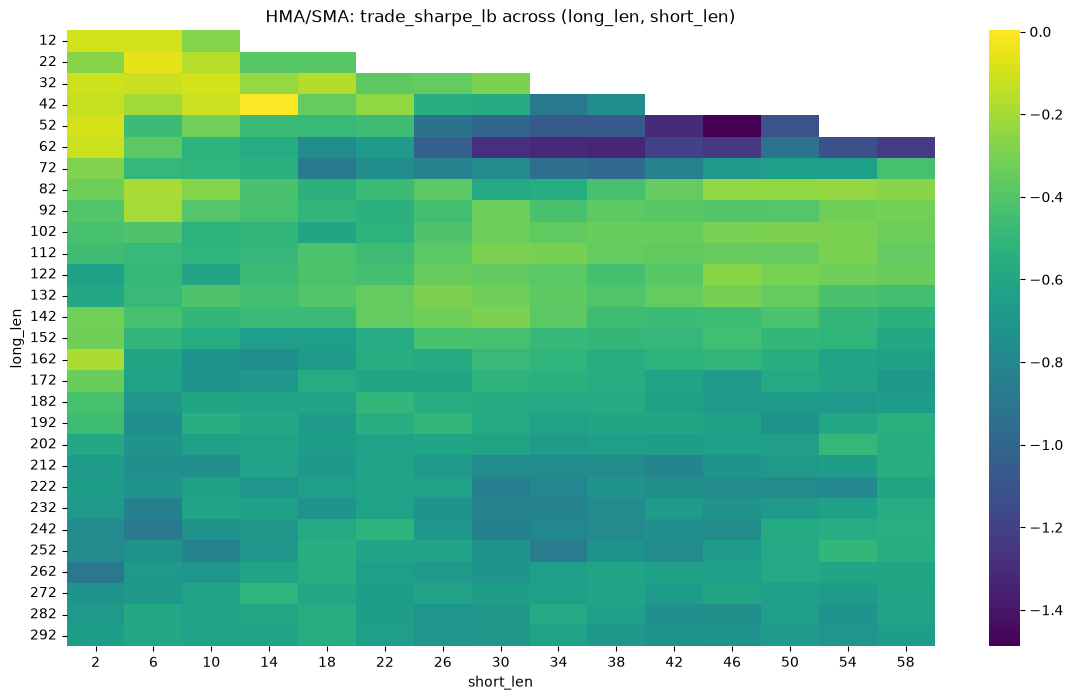

Plateau pick (3x3-smoothed argmax): long_len=22, short_len=2, smoothed trade_sharpe_lb=-0.1263


In [9]:
plot_heatmap("HMA/SMA", hma_sma_results)


## Experiment 4: DEMA(fast) / SMA(slow)

Double Exponential Moving Average for the fast line -- applies EMA twice and combines
them (2*EMA - EMA(EMA)) to cancel out most of a plain EMA's lag at the same length.

In [10]:
dema_sma_fast_fn = lambda w: ta.dema(prices, length=w)  # noqa: E731
dema_sma_slow_fn = lambda w: prices.rolling(w).mean()  # noqa: E731

dema_sma_results = run_grid(dema_sma_fast_fn, dema_sma_slow_fn, combinations)
report_experiment("DEMA/SMA", dema_sma_results)


100%|██████████| 399/399 [00:00<00:00, 744.05it/s]

=== DEMA/SMA: 396/399 combos profitable with >= 10 trades ===


,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
10,32,10,0.196721,0.036407,1.668405,1.733040,2.417717,-0.091496,109,121.378811,0.431193,True
3,22,2,0.154571,-0.073652,1.423744,1.358375,2.178940,-0.079599,246,273.937500,0.317073,True
11,32,14,0.148878,-0.118422,1.330378,1.398668,1.485032,-0.112459,95,105.788872,0.431579,True
39,62,2,0.156285,-0.134845,1.297009,1.479076,1.528739,-0.114723,118,131.400915,0.296610,True
69,82,2,0.141831,-0.159679,1.247439,1.340202,1.268995,-0.125330,101,112.470274,0.277228,True
9,32,6,0.124490,-0.207813,1.154355,1.148432,1.114936,-0.125094,139,154.785823,0.374101,True
61,72,30,0.144348,-0.220006,1.131393,1.254532,1.558231,-0.103891,39,43.429116,0.410256,True
18,42,10,0.128904,-0.220967,1.129592,1.189920,1.203445,-0.120030,89,99.107470,0.449438,True
27,52,6,0.124805,-0.229700,1.113310,1.195574,1.127914,-0.123969,97,108.016006,0.329897,True
5,22,10,0.121213,-0.240613,1.093140,1.124585,1.249520,-0.108664,143,159.240091,0.391608,True


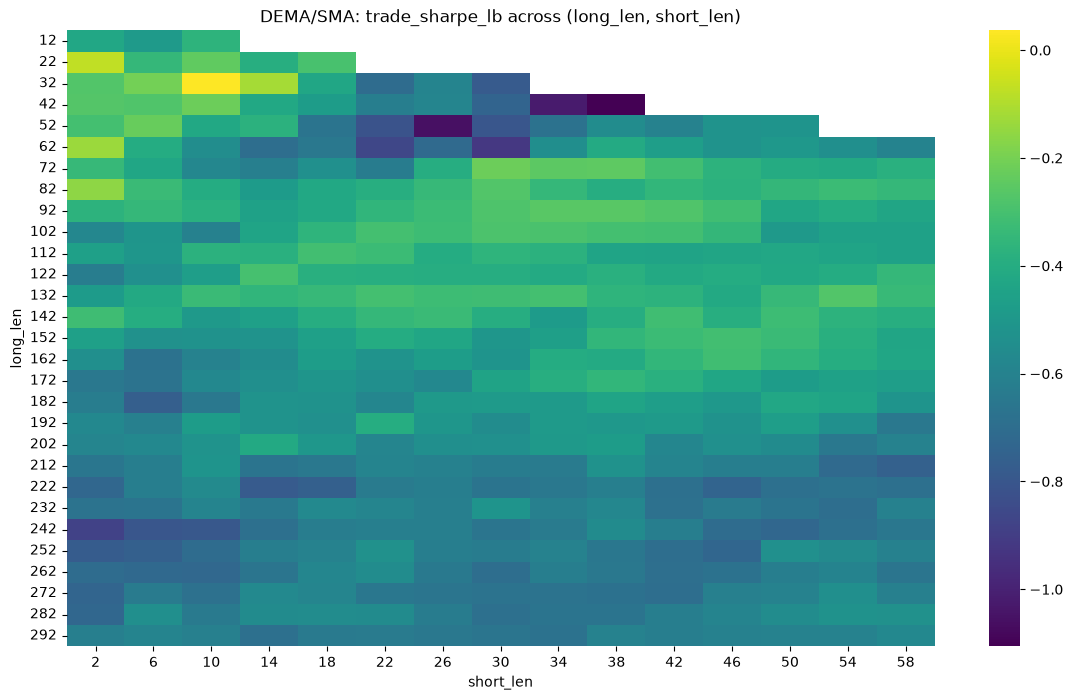

Plateau pick (3x3-smoothed argmax): long_len=32, short_len=6, smoothed trade_sharpe_lb=-0.2076


In [11]:
plot_heatmap("DEMA/SMA", dema_sma_results)


## Cross-experiment comparison

Best (highest `trade_sharpe_lb`) combo from each of the four experiments above, side
by side.

In [12]:
all_experiments = {
    "KAMA/SMA": kama_sma_results,
    "EMA/SMA": ema_sma_results,
    "HMA/SMA": hma_sma_results,
    "DEMA/SMA": dema_sma_results,
}

best_per_experiment = []
for name, results in all_experiments.items():
    candidates = results[(results["total_return"] > 0) & (results["trades"] >= MIN_TRADES)]
    if candidates.empty:
        continue
    best = candidates.sort_values("trade_sharpe_lb", ascending=False).iloc[0].to_dict()
    best["experiment"] = name
    best_per_experiment.append(best)

comparison = pd.DataFrame(best_per_experiment).sort_values("trade_sharpe_lb", ascending=False)
comparison[["experiment", *REPORT_COLUMNS]]


,experiment,long_len,short_len,total_return,trade_sharpe_lb,trade_sharpe,sharpe,calmar,max_drawdown,trades,trades_per_year,win_rate,breaches_tradeify_trail
3,DEMA/SMA,32,10,0.196721,0.036407,1.668405,1.733040,2.417717,-0.091496,109,121.378811,0.431193,True
1,EMA/SMA,32,6,0.194858,0.034719,1.664488,1.719050,2.405526,-0.091080,105,116.924543,0.447619,True
2,HMA/SMA,42,14,0.179351,0.002609,1.590969,1.581069,2.378139,-0.084731,102,113.583841,0.480392,True
0,KAMA/SMA,22,10,0.187840,-0.019724,1.540922,1.603346,2.149969,-0.098201,135,150.331555,0.496296,True


## Out-of-sample check: does the winner hold up on data it never touched?

The cheapest possible overfitting guard (`OPTIMIZATION_RESEARCH_PLAN.md` §5.1): split
the ~1 year of data into the first 75% ("train", what every grid above searched over)
and the last 25% ("test", untouched until now), then re-evaluate the overall winner's
exact parameters on each slice plus the full window. If the strategy's edge is real
rather than a fit to the specific bars in the training slice, performance and
trade-level Sharpe shouldn't collapse on the held-out slice.

In [13]:
# fast/slow line factories, keyed the same way as `all_experiments` above, so the
# winner (whichever experiment it comes from) can be re-evaluated on data subsets.
fast_fns = {
    "KAMA/SMA": kama_sma_fast_fn,
    "EMA/SMA": ema_sma_fast_fn,
    "HMA/SMA": hma_sma_fast_fn,
    "DEMA/SMA": dema_sma_fast_fn,
}
slow_fns = {
    "KAMA/SMA": kama_sma_slow_fn,
    "EMA/SMA": ema_sma_slow_fn,
    "HMA/SMA": hma_sma_slow_fn,
    "DEMA/SMA": dema_sma_slow_fn,
}

winner = comparison.iloc[0]
winner_experiment = winner["experiment"]
winner_long, winner_short = int(winner["long_len"]), int(winner["short_len"])
print(f"Overall winner: {winner_experiment}  long_len={winner_long}  short_len={winner_short}")

split = int(len(prices) * 0.75)
split_date = prices.index[split]
print(f"train/test split at {split_date} ({split} train bars, {len(prices) - split} test bars)\n")

holdout_rows = []
for label, sub_prices in [
    ("FULL (searched over)", prices),
    ("TRAIN (first 75%)", prices.iloc[:split]),
    ("TEST (last 25%, unseen by the grid)", prices.iloc[split:]),
]:
    sub_rs = sub_prices.apply(np.log).diff(1)
    fast = fast_fns[winner_experiment](winner_short)
    slow = slow_fns[winner_experiment](winner_long)
    # re-slice fast/slow to this subset's index (they were computed against the full
    # `prices` series above so each MA's warmup window still sees its true history)
    ma_x = (fast - slow).loc[sub_prices.index]
    row = evaluate_signal(ma_x, sub_prices, sub_rs)
    row["window"] = label
    holdout_rows.append(row)

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
holdout_df[["total_return", "trades", "trade_sharpe", "trade_sharpe_lb", "max_drawdown", "breaches_tradeify_trail"]]


Overall winner: DEMA/SMA  long_len=32  short_len=10
train/test split at 2026-03-11 17:59:59.999000 (3984 train bars, 1329 test bars)



,total_return,trades,trade_sharpe,trade_sharpe_lb,max_drawdown,breaches_tradeify_trail
window,,,,,,
FULL (searched over),0.196721,109,1.668405,0.036407,-0.091496,True
TRAIN (first 75%),0.029762,83,0.487886,-0.801093,-0.069540,True
"TEST (last 25%, unseen by the grid)",0.162134,26,4.150144,-2.393078,-0.033591,False


## Final pick and honest caveats

**Result**: for MNQ, **DEMA(fast)/SMA(slow) wins** -- `long_len=32` (SMA), `short_len=10`
(DEMA), narrowly ahead of EMA/SMA (32/6, +0.035) and HMA/SMA (42/14, +0.003); KAMA/SMA
comes in last and is the only one of the four with a *negative* `trade_sharpe_lb`
(-0.020) for MNQ specifically -- a genuinely different result from both MES (KAMA won)
and M2K (EMA won), underscoring why this 4-way comparison is run per-instrument rather
than assumed. With real Tradeify costs applied, the DEMA/SMA winner returns **+19.7%**
over **109 round-trip trades** (~121/year) -- a `trade_sharpe_lb` of **+0.036**.

**The out-of-sample check above should temper this pick just as it did for MES and
M2K**: the train-only window's `trade_sharpe_lb` is sharply negative (-0.80), and the
test-only window's very high point-estimate Sharpe (4.15) comes from just 26 trades,
giving it a deeply negative lower bound (-2.39) despite looking great on paper. Same
conclusion as the other two instruments: this is *this pass's best defensible answer
given ~1 year of MNQ data*, not a validated edge.

**Also note** (`breaches_tradeify_trail` column above): this pick's own frictionless
equity curve touches roughly a 9.1% drawdown at its worst point, well past Tradeify's
real $2,000/4% trailing-drawdown floor on a $50k Growth account if sized at 100%
exposure the whole time -- similar magnitude to M2K's equivalent (8.1%) and worse than
MES's (4.8%). Worth checking directly against the event-driven notebook's real
position sizing/margin rather than assuming this holds there too.

**Next**: this exact parameter set (DEMA(10)/SMA(32)) is implemented as the single
strategy in `step_2_run_full_backtest.ipynb`, run through the full event-driven
engine (real fills, margin, whole-contract sizing, the Tradeify drawdown middleware)
to see whether the frictionless numbers above hold up under real mechanics.